Loaded existing thermalized state:
/exp/e961/data/MDsims-data/pnichols/Thermalized_States_v3/FCC/n_cells_30/rho_0.710/kT_0.800/nsteps_1000000/seed_1/randomization.gsd
Loaded existing cavitation initial state:
/exp/e961/data/MDsims-data/pnichols/Cavitation_States_v3/FCC/n_cells_30/source_rho_0.710/kT_0.800/source_nsteps_1000000/source_seed_1/source_phase_randomization/radius_5.000/center_box/cavitation_initial.gsd
Loaded existing cavitation evolution:
/exp/e961/data/MDsims-data/pnichols/Cavitation_Evolved_v3/FCC/n_cells_30/source_rho_0.710/kT_0.800/source_nsteps_1000000/source_seed_1/source_phase_randomization/radius_5.000/center_box/evolve_kT_0.800/nsteps_100000/seed_1/cavitation_final.gsd
Evolution status: loaded_evolution
Source status: loaded_source


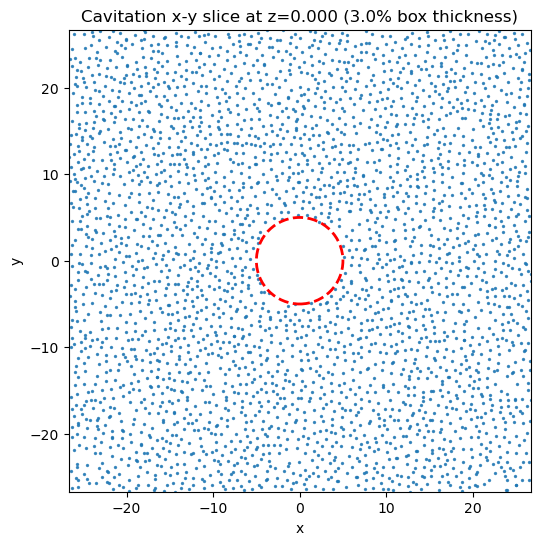

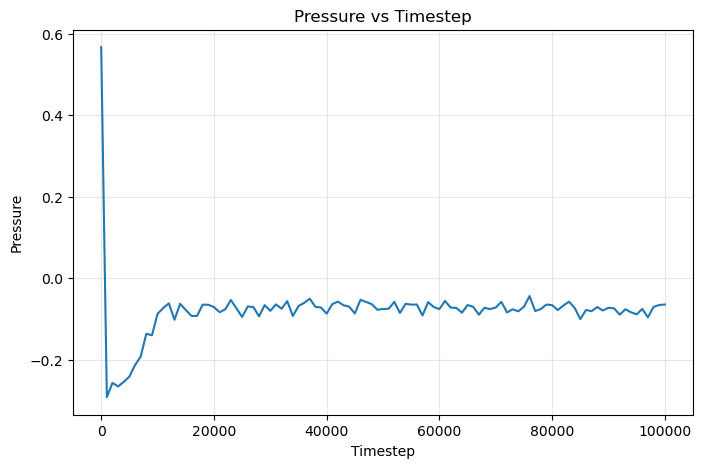

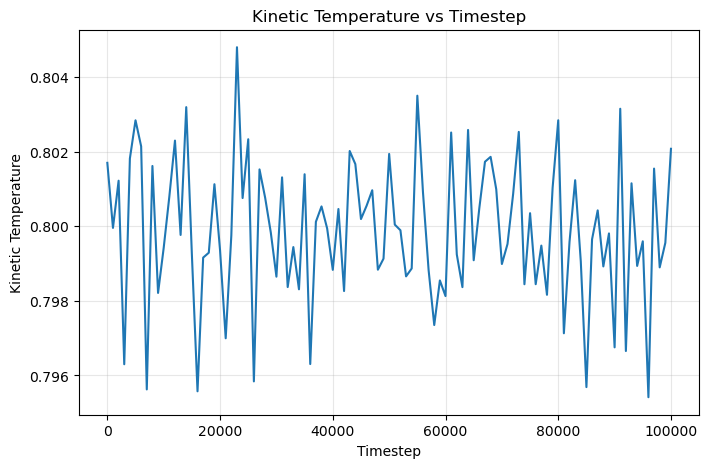

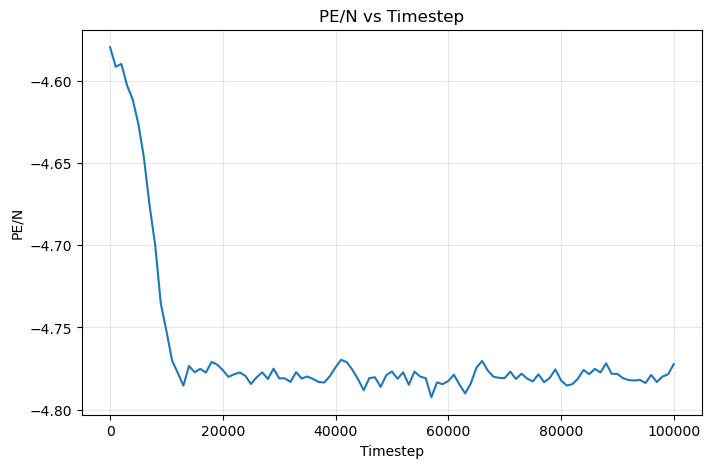

In [10]:
import importlib
from md_Helpers import visualization as vh
importlib.reload(vh)

import importlib
from md_Helpers import cavitation as cav
from md_Helpers import runs

importlib.reload(runs)
importlib.reload(cav)

evolution = cav.get_or_create_cavitation(
    n_fcc_cells=30,
    target_rho=0.71,
    kT=0.80,
    source_nsteps=1_000_000,
    radius=5,
    evolve_nsteps=100_000,

    create_source_if_missing=True,
    overwrite_source=False,
    overwrite=False,
)

print("Evolution status:", evolution["status"])
print("Source status:", evolution["initial_result"]["source_result"]["status"])

vh.plot_cavitation_xy_slice(
    evolution["initial_result"],
    fraction=0.03,
    point_size=2,
    alpha=0.8,
    show_bubble=True,
)

log_path = evolution["paths"]["log_path"]
log = runs.read_hdf5_log(log_path)

vh.plot_log_quantity(log, "pressure")
vh.plot_log_quantity(log, "kinetic_temperature")
vh.plot_log_quantity(log, "potential_energy")

In [12]:
from md_Helpers import classification as ps

log_path = evolution["paths"]["log_path"]

voxel_data, metadata_path = ps.read_phase_method_attrs(
    log_path,
    "voxel",
)

print("Metadata:", metadata_path)
print("Phase separated:", voxel_data["phase_separated"])
print("Low-density fraction:", voxel_data["low_density_fraction"])
print(voxel_data)

Metadata: metadata/classification/phase_separation/voxel
Phase separated: True
Low-density fraction: 0.039
{'density_threshold': 0.2, 'low_density_fraction': 0.039, 'max_voxel_density': 0.8414814257276467, 'mean_voxel_density': 0.7076069901532889, 'method': 'voxel_low_density_fraction', 'min_voxel_density': 0.0, 'n_voxels': 1000, 'nbins': 10, 'phase_separated': True, 'std_voxel_density': 0.14539565900903356, 'updated_from_saved_gsd': True, 'voxel_fraction_threshold': 0.01, 'voxel_volume': 152.11268613483145}


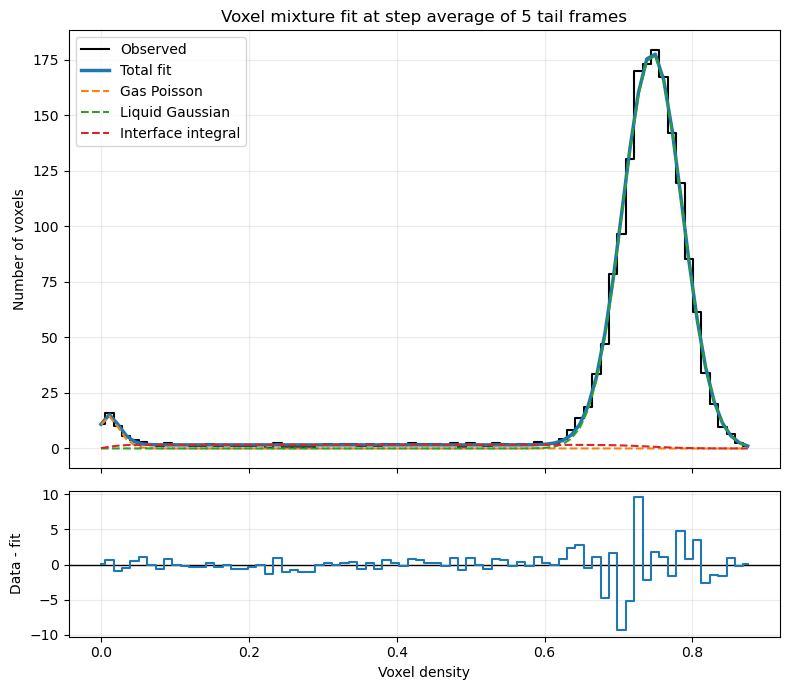

In [26]:
check = vh.fit_and_animate_final_bubble(
    evolution,
    nbins=12,
    nframes=5,
    skip=5,
    tail_fraction=0.2,
)

check["animation"]

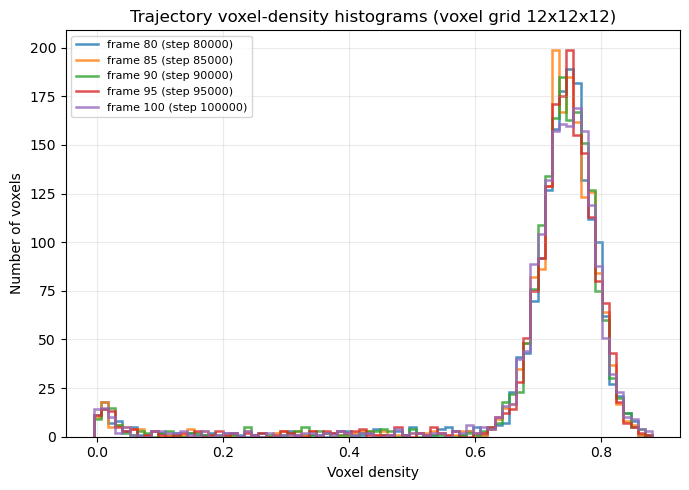

In [27]:
vh.plot_trajectory_voxel_histograms(
    evolution,
    nbins=check['fit']['voxel_nbins'],
    frame_indices=check['fit']['frame_indices'],
);

In [21]:
check.keys()

dict_keys(['fit', 'animation', 'fit_frame_indices', 'video_frame_indices', 'frame_indices', 'bubble_radius', 'bubble_volume', 'bubble_volume_fraction'])

In [22]:
check['bubble_radius']

12.47118489395059